# YOLO: Ajuste Fino sobre un Conjunto de Datos Personalizado

## Why Fine-Tuning Mattersentrenamiento an objeto detector completely from scratch usually requires a large Conjunto de datos, a long entrenamiento run, and careful Hiperparámetro tuning. In practice, we usually start from a **pre-trained YOLO modelo** and adapt it to our own task.Esto es the broad idea of **transfer aprendizaje**: reusing knowledge learned on one Conjunto de datos Para un new task or Conjunto de datos.A more specific term is **fine-tuning**. Fine-tuning means we continue entrenamiento a pre-trained modelo so that its weights adapt to the new Datos. In other words:- **transfer aprendizaje** is the umbrella concept,- **fine-tuning** is one concrete way to do transfer aprendizaje.Why this works:- early layers already encode useful visual patterns such as edges, textures, and parts,- we do not need to relearn those low-level características from zero,- entrenamiento becomes faster and usually needs less labelled Datos.In this notebook Usamos `coco8`, a tiny built-in Conjunto de datos, because it runs quickly. The goal is not to obtain a strong detector, but to understand the workflow:1. inspect the Conjunto de datos format,2. check that labels align with images,3. configure entrenamiento,4. train from pre-trained YOLO weights,5. interpret both numérico metrics and qualitative predicciones.

## Transfer aprendizaje, característica Extraction, and Fine-TuningThese three terms appear together so often that they are frequently confused. They describe different points on a spectrum, not separate techniques.### Transfer aprendizaje**Transfer aprendizaje** is any approach that initialises a modelo with weights learned on a different task or Conjunto de datos rather than random valores. The hypothesis is that a network that has already learned to recognise edges, textures, and objeto parts on ImageNet (or COCO) should need less Datos and fewer iterations to solve a related task.Transfer aprendizaje does **not** specify *which* layers are updated during entrenamiento. That is where característica extraction and fine-tuning come in.### característica Extraction vs Fine-TuningOnce a pre-trained backbone is loaded, there are two extreme strategies:- **característica extraction (frozen backbone):** all backbone layers are frozen — their weights are not updated by gradient descent. Only La tarea-specific head is trained. The backbone acts as a fixed característica extractor, converting images into representations that the new head learns to interpret.- **Full fine-tuning:** every layer in the network, including the backbone, is updated. The pre-trained weights are a *starting point*, not a fixed component.In practice most workflows sit **somewhere in between**: the earliest layers are frozen (they encode very general patterns such as edges and colour gradients) and the remaining layers are updated. YOLO supports this via the `freeze` parámetro:```pythonmodelo.train(Datos=..., freeze=10)    # freeze the first 10 backbone layersmodelo.train(Datos=..., freeze=None)  # fine-tune everything (default)```### The Spectrum| Strategy | Frozen layers | Datos needed | Risk of overfitting ||----------|--------------|-------------|---------------------|| Train from scratch | None (random init) | Large | Low if Datos is large || característica extraction | All backbone | Small | Lower (few free parameters) || Partial fine-tuning | Early backbone | Medium | Medium || Full fine-tuning | None | Medium-large | Higher (all parameters free) |### Catastrophic ForgettingWhen fine-tuning, the network can progressively **forget** what it learned on the source task if the aprendizaje rate is too high. This phenomenon is called **catastrophic forgetting** — the new gradients overwrite the carefully-tuned source weights too aggressively.Practical mitigations:- Use a **lower aprendizaje rate** than you would when entrenamiento from scratch (`lr0=0.001` rather than `lr0=0.01`).- Freeze early layers if source and objetivo domains are similar, to reduce el número de parameters that can be corrupted.- Add regularisation (`weight_decay`, `dropout`).- Use early stopping via the `patience` parámetro: entrenamiento halts automatically if validación metrics stop improving.### What This Notebook Actually DoesWe cargar `yolov8n.pt` and call `modelo.train()` without any `freeze` argumento. Every layer is eligible for gradient updates — Esto es **full fine-tuning**. The default aprendizaje rate is already conservative.Because COCO and coco8 share the same clase conjunto, the head weights change very little and the backbone changes even less. In a genuine domain-transfer scenario (medical images, aerial photographs, or industrial defects) the decision of how much to freeze and what aprendizaje rate to use requires deliberately thinking through the spectrum described above.> **Suggested project**: find a more specialised Conjunto de datos and experiment with different freeze levels and aprendizaje rates to see how they affect entrenamiento speed and final rendimiento.

## Transfer aprendizaje vs Fine-Tuning in This NotebookThere is an important caveat in this demo.Comenzamos from `yolov8n.pt`, which was pre-trained on the COCO Conjunto de datos, and we train on `coco8`, which is a tiny subset of that same general Conjunto de datos family.That means this notebook is excellent for aprendizaje the **mechanics** of YOLO entrenamiento, but it is **not** a strong example of **domain transfer** to genuinely new objeto classes.A more realistic custom-entrenamiento scenario would involve at least one of these changes:- a new clase vocabulary,- a very different visual domain,- or both.So the pedagogical interpretation should be:- this notebook teaches the workflow of preparing, checking, entrenamiento, and evaluating,- a real custom project would require your own Conjunto de datos and more careful validación.

## The YOLO Datos formatYOLO expects three pieces:1. an `images/` directory,2. a `labels/` directory,3. a YAML file that tells the trainer where the Datos lives and what the clase names are.A typical custom Conjunto de datos looks like this:```textomy_dataset/├── images/│   ├── train/│   └── val/├── labels/│   ├── train/│   └── val/└── Datos.yaml```Each image must have a matching label file with the same stem:- `images/train/car_001.jpg`- `labels/train/car_001.txt`Each line in the label file represents one objeto:`<class_id> <x_center> <y_center> <width> <height>`Important details:- coordinates are **normalized** to the interval `[0, 1]`, not stored in pixels,- `class_id` is the entero índice of the clase in the YAML file,- one line means one objeto, so an image with three objects has three lines in its `.txt` file.

## From Label Numbers to Real BoxesYOLO label files store numbers, not drawn rectangles. To check whether the annotations make sense, we must convert those normalized valores back into pixel coordinates.That conversion is not optional bookkeeping. It is one of the most important debugging steps in detection projects, because a modelo will faithfully learn whatever boxes you give it, even if those boxes are wrong.

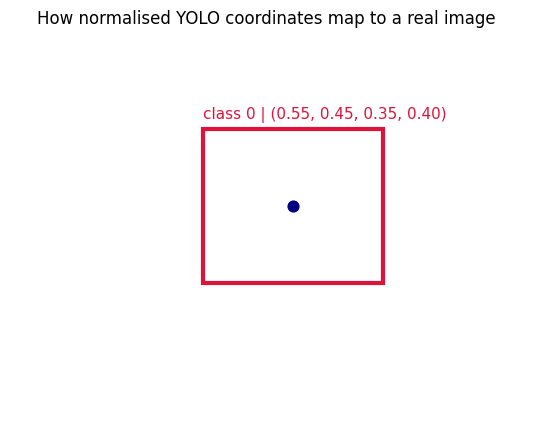

In [ ]:
import matplotlib.pyplot as pltimport matplotlib.patches as patchesimport numpy as np# Suppose the image has this size in pixels.image_width, image_height = 640, 480# Example YOLO annotation: centre x, centre y, width, height.# These valores are normalised to [0, 1].center_x, center_y, box_width_norm, box_height_norm = 0.55, 0.45, 0.35, 0.40# Convert normalised coordinates back to pixel coordinates.left_x = (center_x - box_width_norm / 2) * image_widthtop_y = (center_y - box_height_norm / 2) * image_heightbox_width_px = box_width_norm * image_widthbox_height_px = box_height_norm * image_heightfig, ax = plt.subplots(figsize=(7, 5))ax.imshow(np.ones((image_height, image_width, 3)))rectangle = patches.Rectangle(    (left_x, top_y),    box_width_px,    box_height_px,    linewidth=3,    edgecolor='crimson',    facecolor='none',)ax.add_patch(rectangle)ax.scatter([center_x * image_width], [center_y * image_height], color='navy', s=60)ax.text(    left_x,    top_y - 12,    f'class 0 | ({center_x:.2f}, {center_y:.2f}, {box_width_norm:.2f}, {box_height_norm:.2f})',    color='crimson',    fontsize=11,)ax.set_title('How normalised YOLO coordinates map to a real image')ax.set_axis_off()plt.show()

In [ ]:
from pathlib import Pathfrom PIL import Imagefrom ultralytics import YOLOfrom ultralytics.data.utils import check_det_datasetimport torchimport yamldevice = 'cuda' if torch.cuda.is_available() else 'cpu'print(f'Using device: {device}')

Using device: cpu


## Inspect the Conjunto de datos Before entrenamientoPara un real project, the first question is not "which modelo should I use?" but "is my Conjunto de datos formatted correctly?"We keep execution lightweight by using `coco8`, but the checks below are exactly the ones you should perform on your own Datos:- confirm the YAML file resolves to the expected train and validación folders,- inspect the clase names,- open at least one image,- verify that the label boxes fall on the right objects.This step is where many detection projects succeed or fail. A small Conjunto de datos with correct labels is usually more valuable than a larger Conjunto de datos with sloppy annotations.

In [ ]:
dataset_name = 'coco8.yaml'dataset_info = check_det_dataset(dataset_name)yaml_path = Path(dataset_info['yaml_file']) if 'yaml_file' in dataset_info else Nonedata_root = Path(dataset_info['path'])train_dir = Path(dataset_info['train'])val_dir = Path(dataset_info['val'])class_names = dataset_info['names']if isinstance(class_names, dict):    class_names = [class_names[index] for index in sorted(class_names)]print(f'Using dataset: {dataset_name}')if yaml_path is not None:    print(f'YAML file: {yaml_path}')print(f'Dataset root: {data_root}')print(f'Train images: {train_dir}')print(f'Validation images: {val_dir}')print(f'Classes: {class_names}')

Using dataset: coco8.yaml
YAML file: /media/NOCTURNOEXTRA/Alejandro/wip-clase/.venv/lib/python3.14/site-packages/ultralytics/cfg/datasets/coco8.yaml
Dataset root: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8
Train images: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/train
Validation images: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/val
Classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 

The next cell prints a compact preview of the resolved Conjunto de datos configuration. That is useful because YAML files can mix relative paths, Conjunto de datos roots, and clase dictionaries. Before entrenamiento, it is worth checking that Ultralytics has resolved those fields exactly as you expect.

In [ ]:
def to_yaml_safe(value):    if isinstance(value, dict):        return {key: to_yaml_safe(item) for key, item in value.items()}    if isinstance(value, list):        return [to_yaml_safe(item) for item in value]    if isinstance(value, tuple):        return [to_yaml_safe(item) for item in value]    if isinstance(value, Path):        return str(value)    return valueconfig_preview = {    'path': dataset_info.get('path'),    'train': dataset_info.get('train'),    'val': dataset_info.get('val'),    'names': dataset_info.get('names'),}print('Resolved dataset configuration:')print(yaml.safe_dump(to_yaml_safe(config_preview), sort_keys=False, allow_unicode=True))

Resolved dataset configuration:
path: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8
train: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/train
val: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/val
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
 

## Visual sanity check: one image and its labelsEsto es one of the most valuable checks in an objeto-detection workflow. If the boxes are misplaced here, entrenamiento will faithfully learn the wrong thing.The cell below:- picks one validación image,- loads its `.txt` annotation file,- converts YOLO coordinates back to pixel coordinates,- overlays the boxes on the image.

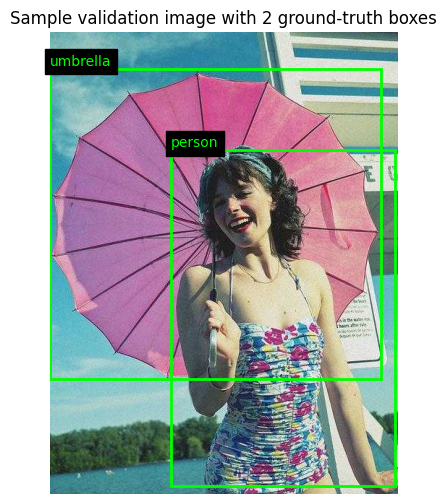

Sample image: 000000000036.jpg
Matching label file: 000000000036.txt


In [ ]:
def find_images(directory: Path) -> list[Path]:    patterns = ('*.jpg', '*.jpeg', '*.png')    image_paths: list[Path] = []    for pattern in patterns:        image_paths.extend(sorted(directory.glob(pattern)))    return image_pathsdef load_yolo_labels(label_path: Path) -> list[tuple[int, float, float, float, float]]:    annotations: list[tuple[int, float, float, float, float]] = []    if not label_path.exists():        return annotations    for line in label_path.read_text().splitlines():        parts = line.split()        if len(parts) != 5:            continue        class_id, cx, cy, w, h = parts        annotations.append((int(class_id), float(cx), float(cy), float(w), float(h)))    return annotationsval_images = find_images(val_dir)sample_image_path = val_images[0]label_image = Image.open(sample_image_path).convert('RGB')image_width, image_height = label_image.sizesample_label_path = Path(str(sample_image_path).replace('/images/', '/labels/')).with_suffix('.txt')annotations = load_yolo_labels(sample_label_path)fig, ax = plt.subplots(figsize=(8, 6))ax.imshow(label_image)for class_id, cx, cy, w, h in annotations:    x1 = (cx - w / 2) * image_width    y1 = (cy - h / 2) * image_height    rect = patches.Rectangle(        (x1, y1),        w * image_width,        h * image_height,        linewidth=2,        edgecolor='lime',        facecolor='none',    )    ax.add_patch(rect)    ax.text(x1, y1 - 4, class_names[class_id], color='lime', fontsize=10, backgroundcolor='black')ax.set_title(f'Sample validation image with {len(annotations)} ground-truth boxes')ax.set_axis_off()plt.show()print(f'Sample image: {sample_image_path.name}')print(f'Matching label file: {sample_label_path.name}')

## entrenamiento ConfigurationVamos a fine-tune `yolov8n.pt`, the **nano** version of YOLO.What that means in practice:- El modeloo starts from weights learned previously on COCO,- entrenamiento continues on the objetivo Conjunto de datos instead of starting from random weights,- the run is therefore an example of transfer aprendizaje, and more specifically fine-tuning.Because this demo still uses `coco8`, it mainly teaches the entrenamiento mechanics. A true custom project would replace `coco8` with a Conjunto de datos whose classes or visual domain differ meaningfully from the original COCO pre-entrenamiento Datos.| parámetro | Demo valor | Why it matters ||---|---:|---|| `modelo` | `yolov8n.pt` | Smaller modelos train faster; larger modelos usually achieve better precisión. || `epochs` | `5` | Good Para un fast demo, but far too small for most real projects. || `imgsz` | `640` | Higher resolution can help small objects but increases compute and memory costo. || `batch` | `8` | More images per update can stabilise entrenamiento, but require more GPU memory. || `device` | `cuda` or `cpu` | GPU is much faster; CPU is acceptable only for tiny demos. |Two useful perspectives:- **Demo setting**: very small number of epochs so the notebook finishes quickly.- **Real project setting**: more Datos, more epochs, repeated label checking, and repeated validación.The point of this run is to understand the pipeline and La salidas, not to squeeze the best possible score from `coco8`.

In [ ]:
model = YOLO('yolov8n.pt')run_name = 'coco8_custom_training_demo'train_results = model.train(    data=dataset_name,    epochs=5,          # 5 is enough for a demo; real projects typically need 50–200.    imgsz=640,         # Inference resolution. Affects memory quadratically (2× size = 4× RAM).    batch=8,           # Frames per gradient update. Increase if GPU has spare memory.    device=device,    project='yolo_outputs',    name=run_name,    plots=True,        # Save pérdida/metric plots to the run directory.    verbose=True,    # patience=50,     # Early stopping: halt if mAP50 doesn't improve for N epochs.    # lr0=0.01,        # Initial aprendizaje rate (default usually works well).    # augment=True,    # Mosaic, flip, scale augmentations (enabled by default).)train_artifacts_dir = Path(model.trainer.save_dir)print(f'Training artifacts saved to: {train_artifacts_dir}')

New https://pypi.org/project/ultralytics/8.4.34 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.22 🚀 Python-3.14.0 torch-2.10.0+cu128 CPU (Intel Core i5-10500 3.10GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=coco8_custom_training_demo2, n

## Read the entrenamiento plotsUltralytics saves figures during entrenamiento, so Podemos inspect the run without writing much extra plotting code.What to look for:- **`box_loss`** (bounding-box regresión pérdida): how far predicted boxes are from ground truth. Should decrease.- **`cls_loss`** (clasificación pérdida): how wrong the clase predicciones are. Should decrease.- **`dfl_loss`** (distribución focal pérdida): fine-grained box localisation quality. Should decrease.- **Precision and Recall curves** should generally move upward.- **mAP50 and mAP50-95** should increase over epochs.With a tiny Conjunto de datos like `coco8`, the curves may be noisy — focus on the overall direction rather than expecting perfectly smooth behavior.

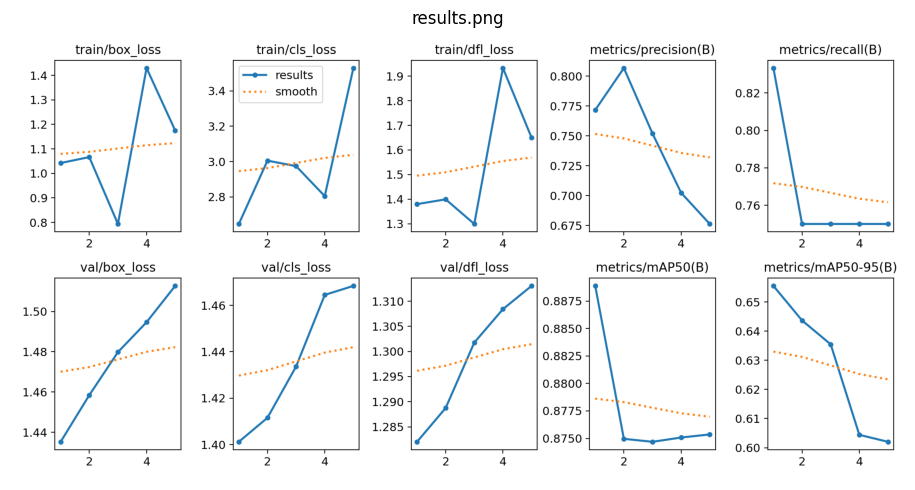

In [ ]:
results_png = train_artifacts_dir / 'results.png'if results_png.exists():    fig, ax = plt.subplots(figsize=(12, 5))    ax.imshow(Image.open(results_png))    ax.set_title('results.png')    ax.set_axis_off()    plt.tight_layout()    plt.show()else:    print('results.png was not found in the run directory.')

## Reading the entrenamiento plots`resultados.png` shows one panel per logged metric across epochs. The key signals to look for:- **`box_loss`**, **`cls_loss`**, **`dfl_loss`** (left columna): entrenamiento and validación losses should both decrease over epochs. A large gap between entrenamiento and validación pérdida is a sign of overfitting.- **Precision and Recall** (middle columna): should generally rise. A modelo with high precision but low recall misses many objects; the opposite means it fires too often with wrong boxes.- **mAP50 and mAP50-95** (right columna): media Average Precision at IoU threshold 0.50, and averaged over thresholds 0.50–0.95. Both should increase over epochs.On a tiny Conjunto de datos such as `coco8`, the curves will be noisy. Focus on the overall direction rather than expecting smooth monotonic behaviour.

## evaluación metricsAfter entrenamiento, we evaluate on the validación conjunto.The two most common detection metrics are:- **mAP50**: a predicción counts as correct if its box overlaps the ground-truth box with IoU ≥ 0.5. Esto es the easier metric.- **mAP50-95**: average score over stricter IoU thresholds from 0.50 to 0.95. Better picture of box-placement quality.A useful rule of thumb:- if `mAP50` is much higher than `mAP50-95`, El modeloo roughly finds objects but box placement needs improvement,- if both are low, consider more Datos, cleaner labels, more epochs, or a larger modelo.**Conjunto de datos split rule of thumb:** aim for roughly **80 % train / 10 % val / 10 % prueba**. Never evaluate on the entrenamiento conjunto — it will look perfect and tell you nothing useful.

In [ ]:
metrics = model.val(split='val')print(f'mAP50: {metrics.box.map50:.3f}')print(f'mAP50-95: {metrics.box.map:.3f}')print(f'Precision: {metrics.box.mp:.3f}')print(f'Recall: {metrics.box.mr:.3f}')

Ultralytics 8.4.22 🚀 Python-3.14.0 torch-2.10.0+cu128 CPU (Intel Core i5-10500 3.10GHz)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2166.9±872.6 MB/s, size: 54.0 KB)
val: Scanning /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.4it/s 0.3s
                   all          4         17      0.771      0.833      0.889      0.655
                person          3         10      0.946        0.5      0.525      0.286
                   dog          1          1      0.639          1      0.995      0.697
                 horse          1          2      0.831          1      0.995      0.747
              elephant          1          2      0.841        0.5      0.828      0.313
              umbrella    

## Qualitative inspection of prediccionesMetrics summarize El modeloo, but they do not tell the full story. We should also inspect at least one predicción visually.Questions to ask when you look at a predicción:- Did El modeloo find the right objeto classes?- Are the boxes tight around the objects?- Did it miss obvious objects?- Are there false positives with low confidence?

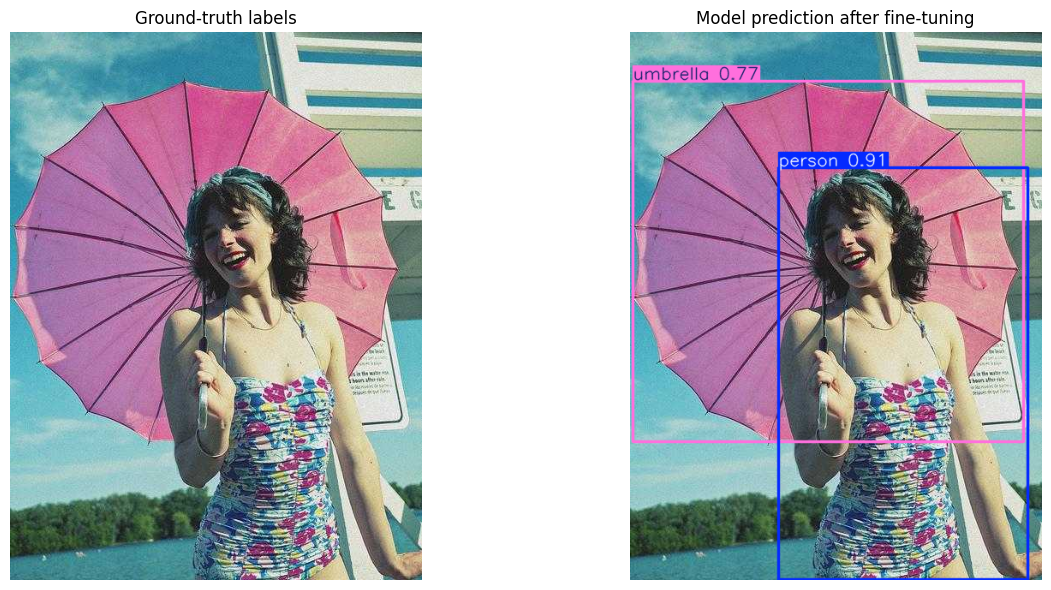

person: confidence=0.91
umbrella: confidence=0.77


In [ ]:
prediction_results = model.predict(source=str(sample_image_path), conf=0.25, verbose=False)annotated_image = prediction_results[0].plot()[:, :, ::-1]fig, axes = plt.subplots(1, 2, figsize=(14, 6))axes[0].imshow(label_image)axes[0].set_title('Ground-truth labels')axes[0].set_axis_off()axes[1].imshow(annotated_image)axes[1].set_title('Model prediction after fine-tuning')axes[1].set_axis_off()plt.tight_layout()plt.show()for box in prediction_results[0].boxes[:5]:    class_id = int(box.cls.item())    confidence = float(box.conf.item())    print(f'{class_names[class_id]}: confidence={confidence:.2f}')

## Inference with the fine-tuned modeloOnce entrenamiento is complete, inference uses the same `modelo.predict()` interface as a pre-trained modelo. The difference is that the weights now reflect the Conjunto de datos we just used for fine-tuning.In a real project, Esto es the moment to prueba images that were **not** part of entrenamiento and validación.

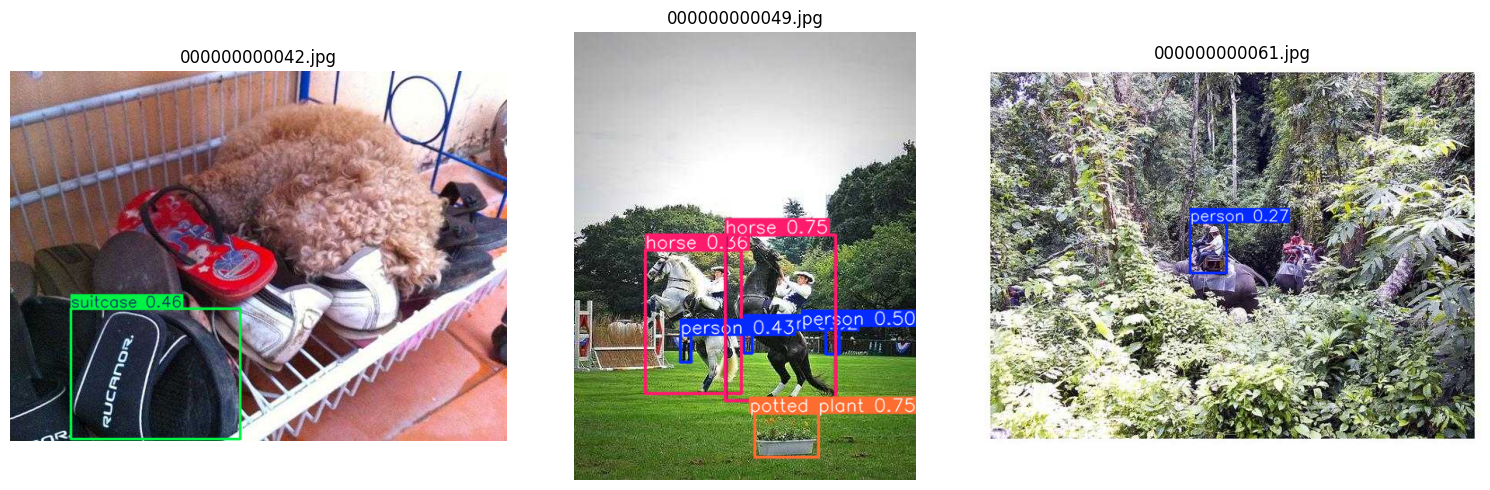

In [ ]:
extra_images = val_images[1:4]if extra_images:    fig, axes = plt.subplots(1, len(extra_images), figsize=(5 * len(extra_images), 5))    if len(extra_images) == 1:        axes = [axes]    for ax, image_path in zip(axes, extra_images):        result = model.predict(source=str(image_path), conf=0.25, verbose=False)[0]        ax.imshow(result.plot()[:, :, ::-1])        ax.set_title(image_path.name)        ax.set_axis_off()    plt.tight_layout()    plt.show()else:    print('No extra validation images were found for inference.')

## Custom Conjunto de datos YAML referenceWhen you switch from `coco8` to your own Conjunto de datos, the YAML file becomes the contract between your files and the trainer.A minimal example is:```yamlpath: ../Conjunto de datoss/my_datasettrain: images/trainval: images/valprueba: images/prueba  # optionalnames:  0: person  1: bicycle  2: car```Checklist before entrenamiento:- `path` points to the Conjunto de datos root,- the `train` and `val` folders actually exist,- every image has a matching `.txt` label file,- every `class_id` used in the labels appears in `names`,- the boxes are normalized to `[0, 1]` and not stored in pixels.If any of these assumptions are wrong, entrenamiento may still run, but El modeloo quality will be poor or misleading.

## TroubleshootingCommon issues in small custom-entrenamiento experiments:- **entrenamiento is very slow**: this usually means the notebook is running on CPU. That is acceptable Para un tiny demo, but not Para un real entrenamiento workflow.- **Metrics stay low**: the most common causes are too few epochs, too little Datos, or poor label quality.- **predicciones find the objeto but the box is sloppy**: this often appears as a reasonable `mAP50` but a noticeably lower `mAP50-95`.- **No detections appear**: check clase IDs, label normalización, and whether the label files match the image stems.- **The notebook runs without errors but resultados make no sense**: always go back to the visual sanity check cell and inspect the annotations again.

## Export for deploymentAfter entrenamiento, Podemos export El modeloo for use outside the notebook.Why export?- `onnx` is a common interchange format for production systems,- deployment often happens in a different environment from entrenamiento,- exporting is the last step after we are satisfied with both the metrics and the qualitative predicciones.

In [ ]:
path = model.export(format="onnx")print(f"Model exported to {path}")

Ultralytics 8.4.22 🚀 Python-3.14.0 torch-2.10.0+cu128 CPU (Intel Core i5-10500 3.10GHz)

PyTorch: starting from '/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.0s, saved as '/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights/best.onnx' (12.3 MB)

Export complete (1.2s)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights
Predict:         yolo predict task=detect model=/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_trai

## SummaryIn this notebook we followed the full fine-tuning workflow for objeto detection:- understand the YOLO annotation format,- inspect the Conjunto de datos before entrenamiento,- fine-tune a pre-trained YOLO modelo,- interpret entrenamiento curves and validación metrics,- inspect predicciones visually,- export the trained modelo.The most important practical lesson is that **Conjunto de datos quality and label correctness matter as much as modelo choice**.The most important conceptual lesson is that **transfer aprendizaje** is the broad reuse of pre-trained knowledge, while **fine-tuning** is the specific act of continuing entrenamiento on new Datos.Finally, remember the caveat of this demo: `coco8` is ideal for aprendizaje the workflow quickly, but a real custom-entrenamiento project should use genuinely custom Datos and a more serious validación setup.A natural next step is to replace `coco8` with your own Conjunto de datos and repeat the same inspection-first workflow.